In [1]:
# =========================
# Core libraries
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint

# =========================
# Sklearn / Imbalanced-learn
# =========================
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# =========================
# Utilities
# =========================
from IPython.display import Markdown, display

# =========================
# Reproducibility
# =========================
import joblib
SEED = 0
np.random.seed(SEED)

In [2]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/TCGA InfiniumPurify Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((494, 19277), (123, 19277), (494,), (123,))

In [3]:
# =========================
# RFE + RS Pipeline
# =========================

display(Markdown("# RFE + Randomized Search"))

# =========================
# Pipeline with RFE
# =========================
pipeline_rfe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("rfe", RFE(
        estimator=RandomForestClassifier(random_state=SEED)
    )),
    ("rf", RandomForestClassifier(random_state=SEED))
])

# =========================
# Parameter distributions
# =========================
param_dist_rfe = { 
    'rfe__n_features_to_select': [100, 500, 1000],
    'rfe__step': [0.2, 0.25, 0.5],
    
    'rf__n_estimators': randint(50, 300),
    'rf__max_depth': [None] + list(range(5, 31, 5)),
    'rf__max_features': ['sqrt', 'log2'],
    'rf__min_samples_split': randint(2, 10),
    'rf__min_samples_leaf': randint(1, 5)
}

# (ranges before the best was found)
#'rf__n_estimators': randint(50, 300),
#'rf__max_depth': [None] + list(range(5, 31, 5)),
#'rf__max_features': ['sqrt', 'log2'],
#'rf__min_samples_split': randint(2, 10),
#'rf__min_samples_leaf': randint(1, 5)

# RFE + Randomized Search

In [4]:
# =========================
# Training RFE + RS Model
# =========================

random_search_rfe = RandomizedSearchCV(
    pipeline_rfe,
    param_distributions=param_dist_rfe,
    n_iter=50,
    cv=5,
    scoring="f1_weighted",
    random_state=SEED,
    n_jobs=-1,
    verbose=2
)

random_search_rfe.fit(X_train, y_train)

best_model_rfe = random_search_rfe.best_estimator_

print("Best parameters:")
print(random_search_rfe.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters:
{'rf__max_depth': 25, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 4, 'rf__n_estimators': 212, 'rfe__n_features_to_select': 100, 'rfe__step': 0.25}


Accuracy: 0.7723577235772358
              precision    recall  f1-score   support

       Basal       0.93      0.82      0.88        17
        Her2       1.00      0.33      0.50         6
        LumA       0.81      0.82      0.82        57
        LumB       0.61      0.65      0.63        26
      Normal       0.75      0.88      0.81        17

    accuracy                           0.77       123
   macro avg       0.82      0.70      0.73       123
weighted avg       0.79      0.77      0.77       123



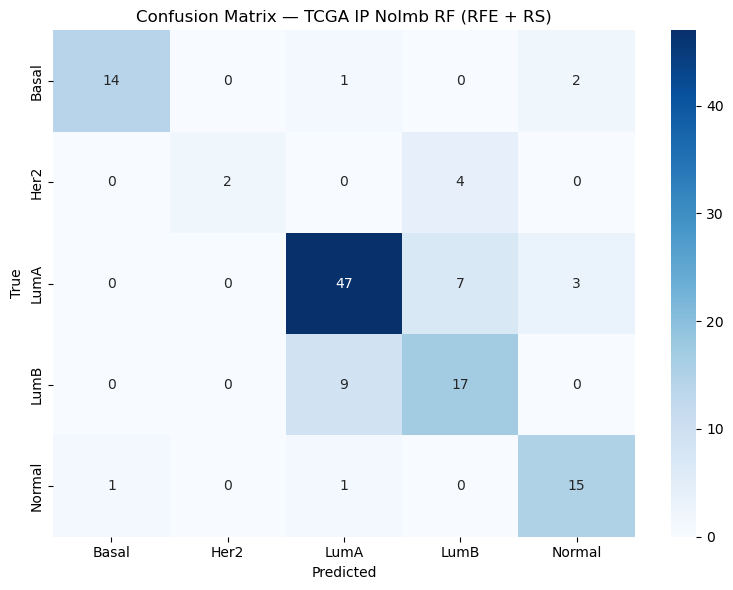

In [5]:
# =========================
# RFE + RS Model Evaluation
# =========================

y_pred_rfe = best_model_rfe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rfe))
print(classification_report(y_test, y_pred_rfe))

cm = confusion_matrix(y_test, y_pred_rfe)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test),
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — TCGA IP NoImb RF (RFE + RS)")
plt.tight_layout()
plt.show()

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_40700\3328365973.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


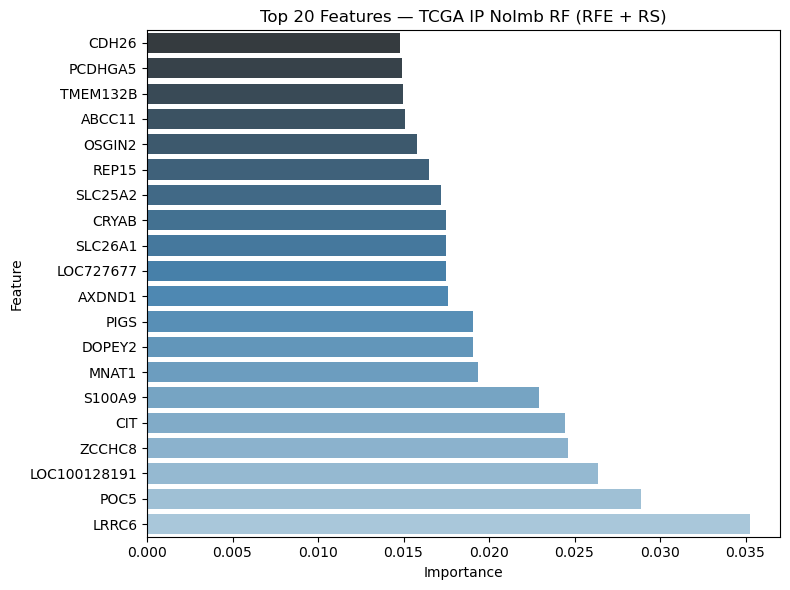

In [6]:
# =========================
# Model Feature Importance
# =========================

rfe = best_model_rfe.named_steps["rfe"]
rf_inner = rfe.estimator_

selected_mask = rfe.support_
selected_features = X_train.columns[selected_mask]

importances = rf_inner.feature_importances_

rfe_importances = (
    pd.DataFrame({
        "Feature": selected_features,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

top_20_rfe = rfe_importances.head(20)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_20_rfe,
    x="Importance",
    y="Feature",
    palette="Blues_d"
)
plt.gca().invert_yaxis()
plt.title("Top 20 Features — TCGA IP NoImb RF (RFE + RS)")
plt.tight_layout()
plt.show()

In [7]:
# =========================
# RS Pipeline
# =========================

display(Markdown("# Random Search (No RFE)"))

pipeline_no_rfe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=SEED))
])

param_dist_no_rfe = {
    'rf__n_estimators': randint(50, 300),
    'rf__max_depth': [None] + list(range(5, 31, 5)),
    'rf__max_features': ['sqrt', 'log2'],
    'rf__min_samples_split': randint(2, 10),
    'rf__min_samples_leaf': randint(1, 5),
}

# (ranges before the best was found)
# 'rf__n_estimators': randint(50, 300),
# 'rf__max_depth': [None] + list(range(5, 31, 5)),
# 'rf__max_features': ['sqrt', 'log2'],
# 'rf__min_samples_split': randint(2, 10),
# 'rf__min_samples_leaf': randint(1, 5),

# Random Search (No RFE)

In [8]:
# =========================
# Training RS Model
# =========================

random_search_no_rfe = RandomizedSearchCV(
    pipeline_no_rfe,
    param_distributions=param_dist_no_rfe,
    n_iter=50,
    cv=5,
    scoring="f1_weighted",
    random_state=SEED,
    n_jobs=-1,
    verbose=2
)

random_search_no_rfe.fit(X_train, y_train)

best_model_no_rfe = random_search_no_rfe.best_estimator_

print("Best parameters:")
print(random_search_no_rfe.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters:
{'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 5, 'rf__n_estimators': 224}


Accuracy: 0.7560975609756098
              precision    recall  f1-score   support

       Basal       0.94      0.88      0.91        17
        Her2       1.00      0.17      0.29         6
        LumA       0.70      0.86      0.77        57
        LumB       0.68      0.50      0.58        26
      Normal       0.88      0.88      0.88        17

    accuracy                           0.76       123
   macro avg       0.84      0.66      0.69       123
weighted avg       0.77      0.76      0.74       123



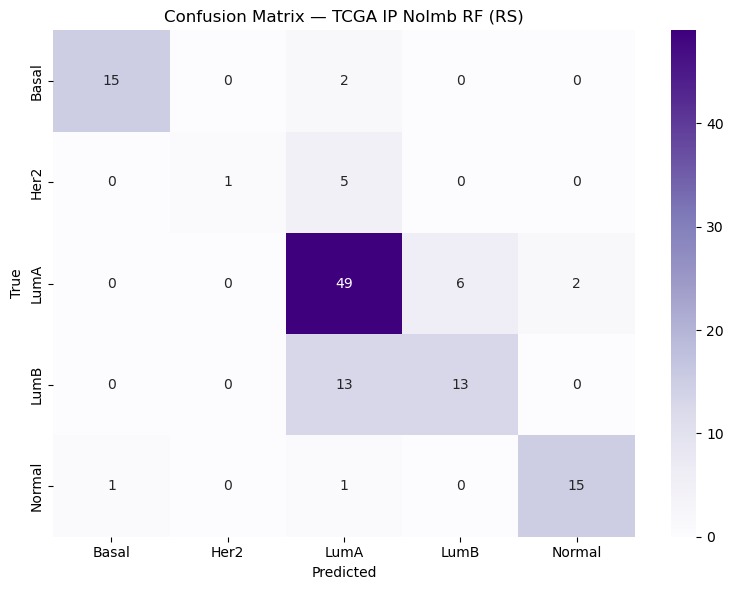

In [9]:
# =========================
# RS Model Evaluation
# =========================

y_pred_no_rfe = best_model_no_rfe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_no_rfe))
print(classification_report(y_test, y_pred_no_rfe))

cm = confusion_matrix(y_test, y_pred_no_rfe)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Purples",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test),
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — TCGA IP NoImb RF (RS)")
plt.tight_layout()
plt.show()

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_40700\2012722017.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


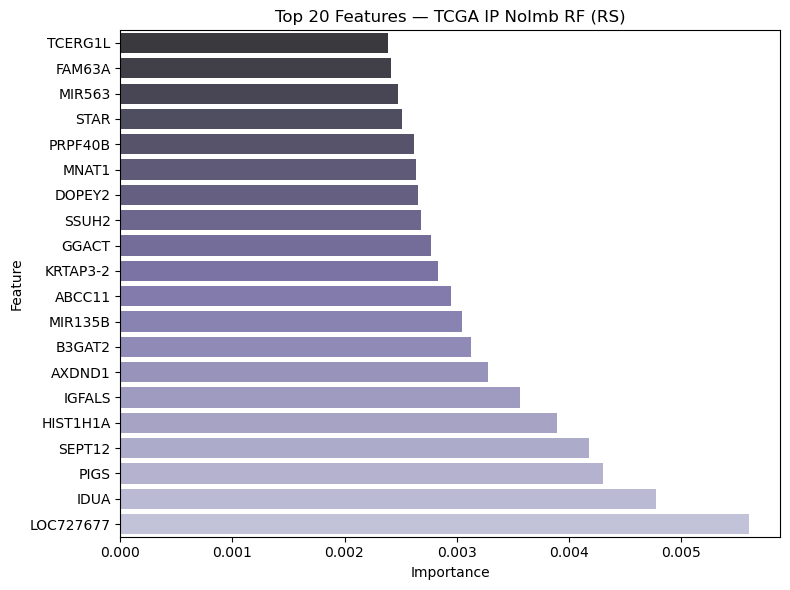

In [10]:
# =========================
# Model Feature Importance
# =========================

rf_model = best_model_no_rfe.named_steps["rf"]

feat_imp = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

top_20_no_rfe = feat_imp.head(20)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_20_no_rfe,
    x="Importance",
    y="Feature",
    palette="Purples_d"
)
plt.gca().invert_yaxis()
plt.title("Top 20 Features — TCGA IP NoImb RF (RS)")
plt.tight_layout()
plt.show()


Evaluating: TCGA IP NoImb RF Random Search + RFE
TCGA IP NoImb RF Random Search + RFE — F1 (weighted): 0.7693
TCGA IP NoImb RF Random Search + RFE — Macro AUC-PR: 0.895
TCGA IP NoImb RF Random Search + RFE — Macro Average Precision: 0.898


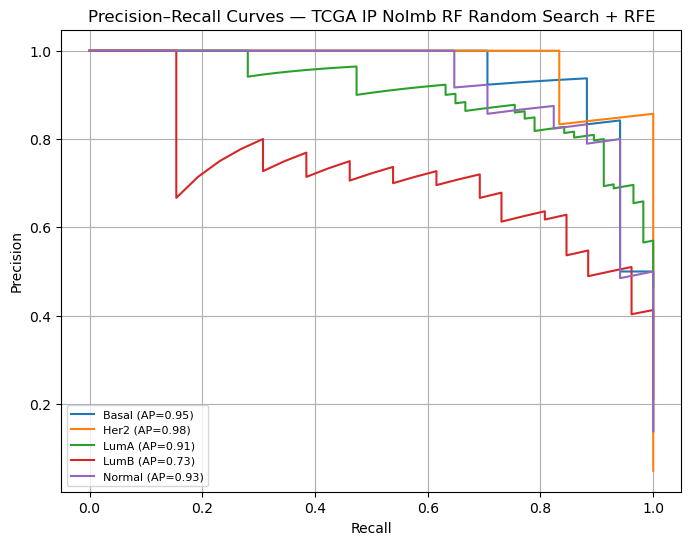


Evaluating: TCGA IP NoImb RF Random Search
TCGA IP NoImb RF Random Search — F1 (weighted): 0.7413
TCGA IP NoImb RF Random Search — Macro AUC-PR: 0.828
TCGA IP NoImb RF Random Search — Macro Average Precision: 0.835


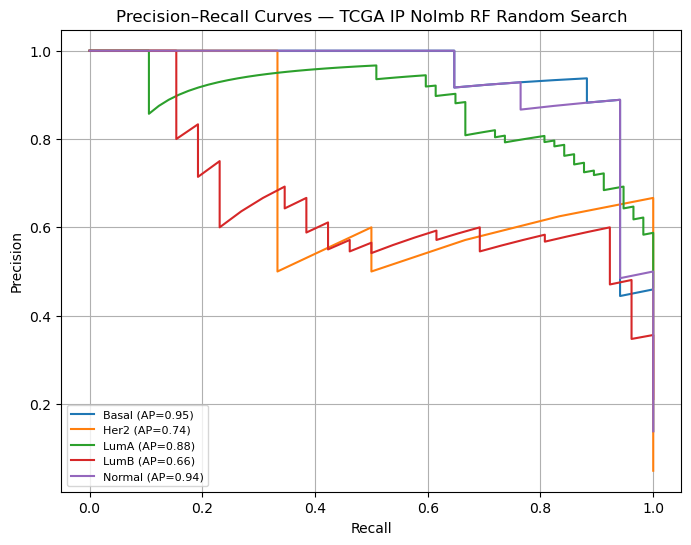


AUC-PR Per Model Per Subtype

TCGA IP NoImb RF Random Search + RFE
  Basal: AUC-PR = 0.949, AP = 0.950
  Her2: AUC-PR = 0.974, AP = 0.976
  LumA: AUC-PR = 0.905, AP = 0.906
  LumB: AUC-PR = 0.720, AP = 0.727
  Normal: AUC-PR = 0.928, AP = 0.929

TCGA IP NoImb RF Random Search
  Basal: AUC-PR = 0.944, AP = 0.945
  Her2: AUC-PR = 0.722, AP = 0.744
  LumA: AUC-PR = 0.878, AP = 0.880
  LumB: AUC-PR = 0.655, AP = 0.663
  Normal: AUC-PR = 0.940, AP = 0.941


In [11]:
# =========================
# Precision–Recall Curves
# =========================

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

models = {
    "TCGA IP NoImb RF Random Search + RFE": best_model_rfe,
    "TCGA IP NoImb RF Random Search": best_model_no_rfe,
}

results = {}

for name, model in models.items():
    print(f"\nEvaluating: {name}")
    plt.figure(figsize=(8, 6))

    y_score = model.predict_proba(X_test)
    results[name] = {}

    y_pred = model.predict(X_test)
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    print(f"{name} — F1 (weighted): {f1_weighted:.4f}")
    
    for i, cls in enumerate(classes):
        precision, recall, _ = precision_recall_curve(
            y_test_bin[:, i], y_score[:, i]
        )

        # AUC of PR curve
        auc_pr = auc(recall, precision)

        # Average Precision
        ap = average_precision_score(
            y_test_bin[:, i], y_score[:, i]
        )

        # Store AUC-PR per subtype
        results[name][cls] = {
            "AUC_PR": auc_pr,
            "Average_Precision": ap
        }

        plt.plot(recall, precision, label=f"{cls} (AP={ap:.2f})")

    # Compute macro averages
    macro_auc = np.mean(
        [results[name][cls]["AUC_PR"] for cls in classes]
    )

    macro_ap = np.mean(
        [results[name][cls]["Average_Precision"] for cls in classes]
    )

    print(f"{name} — Macro AUC-PR: {macro_auc:.3f}")
    print(f"{name} — Macro Average Precision: {macro_ap:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curves — {name}")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

print("\n=========================")
print("AUC-PR Per Model Per Subtype")
print("=========================")

for model_name, subtype_dict in results.items():
    print(f"\n{model_name}")
    for subtype, metrics in subtype_dict.items():
        print(
            f"  {subtype}: "
            f"AUC-PR = {metrics['AUC_PR']:.3f}, "
            f"AP = {metrics['Average_Precision']:.3f}"
        )

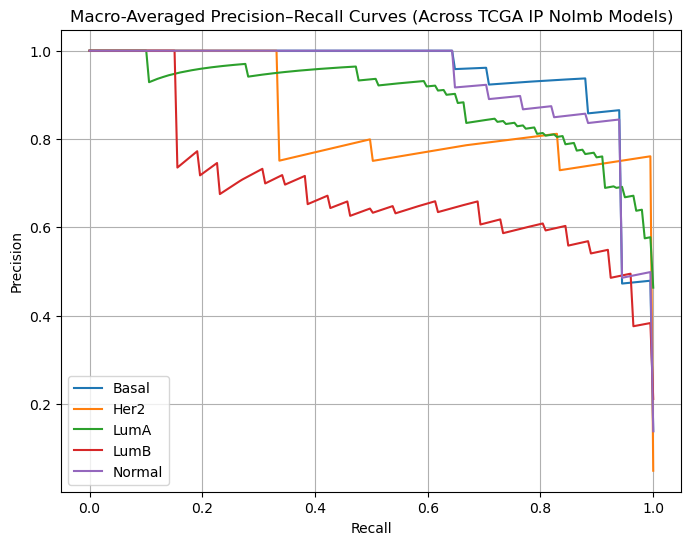

In [12]:
# =========================
# Macro-Averaged PR Curves
# =========================

plt.figure(figsize=(8, 6))
recall_grid = np.linspace(0, 1, 200)

for i, cls in enumerate(classes):
    precisions = []

    for model in models.values():
        y_score = model.predict_proba(X_test)
        p, r, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        precisions.append(np.interp(recall_grid, r[::-1], p[::-1]))

    mean_precision = np.mean(precisions, axis=0)
    plt.plot(recall_grid, mean_precision, label=cls)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Macro-Averaged Precision–Recall Curves (Across TCGA IP NoImb Models)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
joblib.dump(best_model_rfe, "PKL/RF_TCGA_IP_NoImb_RFE.pkl")
joblib.dump(best_model_no_rfe, "PKL/RF_TCGA_IP_NoImb_No_RFE.pkl")

print("Models saved successfully.")

Models saved successfully.
